# 06 — XGBoost + Optuna Hyperparameter Tuning

**Goal:** Establish the best possible MAE on Tier 1+2 composition features before adding Tier 3 structural features.

**What this does:**
1. Loads struct train/test feature CSVs
2. Trains default XGBoost as baseline
3. Runs Optuna (200 trials, 5-fold CV) to find optimal hyperparameters
4. Evaluates tuned model on held-out test set
5. Analyzes feature importance + worst predictions

**How Optuna works:**
- Trial 1-15ish: samples hyperparameters randomly, builds up a dataset of (params → score)
- Trial 15+: fits a Tree-structured Parzen Estimator (TPE) to that dataset — a probabilistic model of which param regions are promising
- Each subsequent trial samples more from promising regions, occasionally exploring elsewhere
- Result: finds good hyperparameters in ~100-200 trials instead of the thousands a grid search would need

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import optuna
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress trial-by-trial spam

## 1. Load Data

Update the paths below to wherever your feature CSVs live.

In [2]:
# UPDATE THESE PATHS
TRAIN_PATH = 'struct_train_features.csv'
TEST_PATH = 'struct_test_features.csv'

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

# Separate features from target
drop_cols = ['id', 'composition', 'log_conductivity']
feature_cols = [c for c in train.columns if c not in drop_cols]

X_train = train[feature_cols].copy()
y_train = train['log_conductivity'].values
X_test = test[feature_cols].copy()
y_test = test['log_conductivity'].values

# Convert any bool/string bools to int
for col in X_train.columns:
    X_train[col] = pd.to_numeric(
        X_train[col].replace({'True': 1, 'False': 0}), errors='coerce'
    )
    X_test[col] = pd.to_numeric(
        X_test[col].replace({'True': 1, 'False': 0}), errors='coerce'
    )

print(f'Train: {X_train.shape[0]} samples, {X_train.shape[1]} features')
print(f'Test:  {X_test.shape[0]} samples')
print(f'Features: {list(feature_cols)}')
print(f'\nTarget stats:')
print(f'  Range: [{y_train.min():.2f}, {y_train.max():.2f}]')
print(f'  Mean:  {y_train.mean():.2f}')
print(f'  Std:   {y_train.std():.2f}')

Train: 339 samples, 16 features
Test:  68 samples
Features: ['li_count', 'mean_electronegativity', 'anion_electronegativity', 'cation_anion_en_diff', 'mean_ionic_radius', 'anion_ionic_radius', 'radius_std', 'anion_polarizability', 'mean_atomic_mass', 'n_elements', 'mean_atomic_number', 'anion_halide', 'anion_mixed', 'anion_other', 'anion_oxide', 'anion_sulfide']

Target stats:
  Range: [-17.38, -1.61]
  Mean:  -5.94
  Std:   3.04


## 2. Default XGBoost Baseline

In [3]:
default_model = xgb.XGBRegressor(
    n_estimators=100,
    random_state=42
)
default_model.fit(X_train, y_train)
default_preds = default_model.predict(X_test)

default_mae = mean_absolute_error(y_test, default_preds)
default_r2 = r2_score(y_test, default_preds)

print(f'Default XGBoost')
print(f'  Test MAE: {default_mae:.4f}')
print(f'  Test R²:  {default_r2:.4f}')

Default XGBoost
  Test MAE: 1.5347
  Test R²:  0.4396


## 3. Optuna Hyperparameter Search

**Search space explained:**
- `n_estimators`: number of boosting rounds (trees). More = more capacity, but slower + risk of overfitting
- `max_depth`: how deep each tree can go. Deeper = can capture more complex interactions, but overfits on small data
- `learning_rate`: how much each tree's correction counts. Smaller = more conservative, needs more trees
- `subsample`: fraction of training samples each tree sees. <1.0 adds randomness, reduces overfitting
- `colsample_bytree`: fraction of features each tree sees. Same idea as subsample but for features
- `min_child_weight`: minimum sum of instance weight in a leaf. Higher = more conservative splits
- `reg_alpha` (L1): pushes feature weights toward zero. Encourages sparsity (feature selection)
- `reg_lambda` (L2): shrinks all weights toward zero. General smoothing
- `gamma`: minimum loss reduction for a split. Higher = fewer splits = simpler trees

With 339 training samples and 16 features, overfitting is the main enemy. Expect Optuna to favor:
- shallow trees (max_depth 3-5)
- moderate-to-strong regularization
- aggressive subsampling

In [4]:
def objective(trial):
    """Optuna objective: minimize 5-fold CV MAE."""
    params = {
        'n_estimators':    trial.suggest_int('n_estimators', 50, 800),
        'max_depth':       trial.suggest_int('max_depth', 2, 8),
        'learning_rate':   trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'subsample':       trial.suggest_float('subsample', 0.4, 1.0),
        'colsample_bytree':trial.suggest_float('colsample_bytree', 0.3, 1.0),
        'min_child_weight':trial.suggest_int('min_child_weight', 1, 20),
        'reg_alpha':       trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':      trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'gamma':           trial.suggest_float('gamma', 0, 5.0),
        'random_state':    42,
    }

    model = xgb.XGBRegressor(**params)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(
        model, X_train, y_train,
        cv=kf, scoring='neg_mean_absolute_error'
    )
    return -scores.mean()  # Optuna minimizes, neg_mae is negative


# Run optimization
study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(objective, n_trials=200, show_progress_bar=True)

print(f'\nBest 5-fold CV MAE: {study.best_value:.4f}')
print(f'Best params:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

  0%|          | 0/200 [00:00<?, ?it/s]


Best 5-fold CV MAE: 1.0921
Best params:
  n_estimators: 717
  max_depth: 8
  learning_rate: 0.036415345592092765
  subsample: 0.6087286268470228
  colsample_bytree: 0.5517166821600895
  min_child_weight: 1
  reg_alpha: 2.433025375078257e-07
  reg_lambda: 1.8314906334075298
  gamma: 0.023942226625465406


## 4. Train Final Model + Evaluate on Test Set

In [5]:
# Train with best hyperparameters on full training set
best_params = {**study.best_params, 'random_state': 42}
tuned_model = xgb.XGBRegressor(**best_params)
tuned_model.fit(X_train, y_train)
tuned_preds = tuned_model.predict(X_test)

tuned_mae = mean_absolute_error(y_test, tuned_preds)
tuned_r2 = r2_score(y_test, tuned_preds)

print('=' * 50)
print(f'Default XGBoost  | MAE: {default_mae:.4f} | R²: {default_r2:.4f}')
print(f'Tuned XGBoost    | MAE: {tuned_mae:.4f} | R²: {tuned_r2:.4f}')
print('=' * 50)
print(f'MAE improvement: {default_mae - tuned_mae:.4f} ({(default_mae - tuned_mae)/default_mae*100:.1f}%)')
print(f'\nFor reference: OBELiX baseline MAE ≈ 0.85')

Default XGBoost  | MAE: 1.5347 | R²: 0.4396
Tuned XGBoost    | MAE: 1.6064 | R²: 0.3983
MAE improvement: -0.0717 (-4.7%)

For reference: OBELiX baseline MAE ≈ 0.85


## 5. Feature Importance

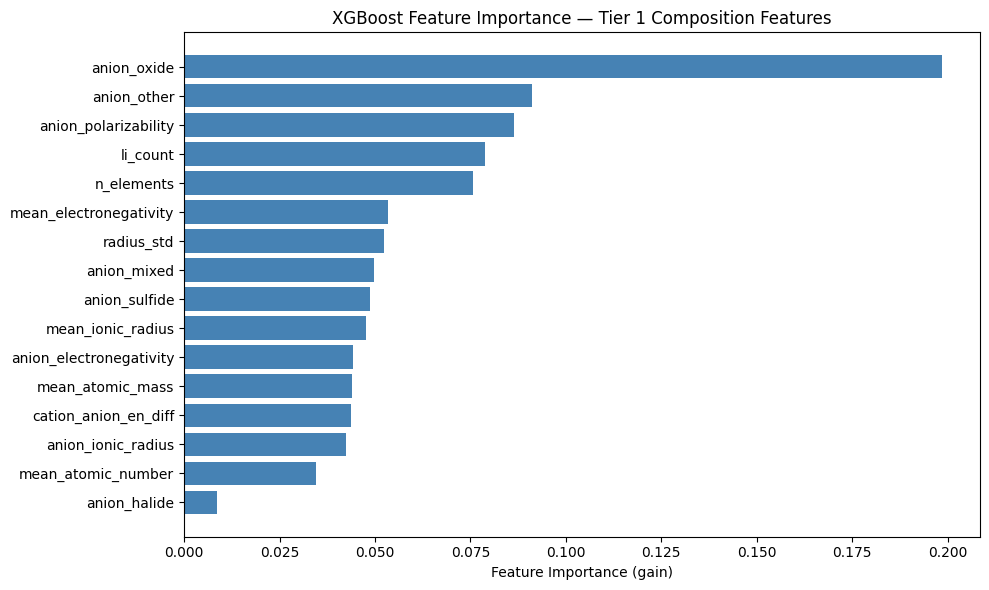


Feature importance (ranked):
  anion_oxide                    0.1985
  anion_other                    0.0911
  anion_polarizability           0.0865
  li_count                       0.0788
  n_elements                     0.0757
  mean_electronegativity         0.0533
  radius_std                     0.0524
  anion_mixed                    0.0498
  anion_sulfide                  0.0488
  mean_ionic_radius              0.0476
  anion_electronegativity        0.0442
  mean_atomic_mass               0.0440
  cation_anion_en_diff           0.0437
  anion_ionic_radius             0.0423
  mean_atomic_number             0.0346
  anion_halide                   0.0087


In [6]:
importances = tuned_model.feature_importances_
feat_imp = sorted(zip(feature_cols, importances), key=lambda x: x[1], reverse=True)

fig, ax = plt.subplots(figsize=(10, 6))
names = [f for f, _ in feat_imp]
vals = [v for _, v in feat_imp]
ax.barh(range(len(names)), vals, color='steelblue')
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance (gain)')
ax.set_title('XGBoost Feature Importance — Tier 1 Composition Features')
plt.tight_layout()
plt.show()

print('\nFeature importance (ranked):')
for fname, imp in feat_imp:
    print(f'  {fname:30s} {imp:.4f}')

## 6. Residual Analysis

Where is the model failing? This tells us what physics is missing.

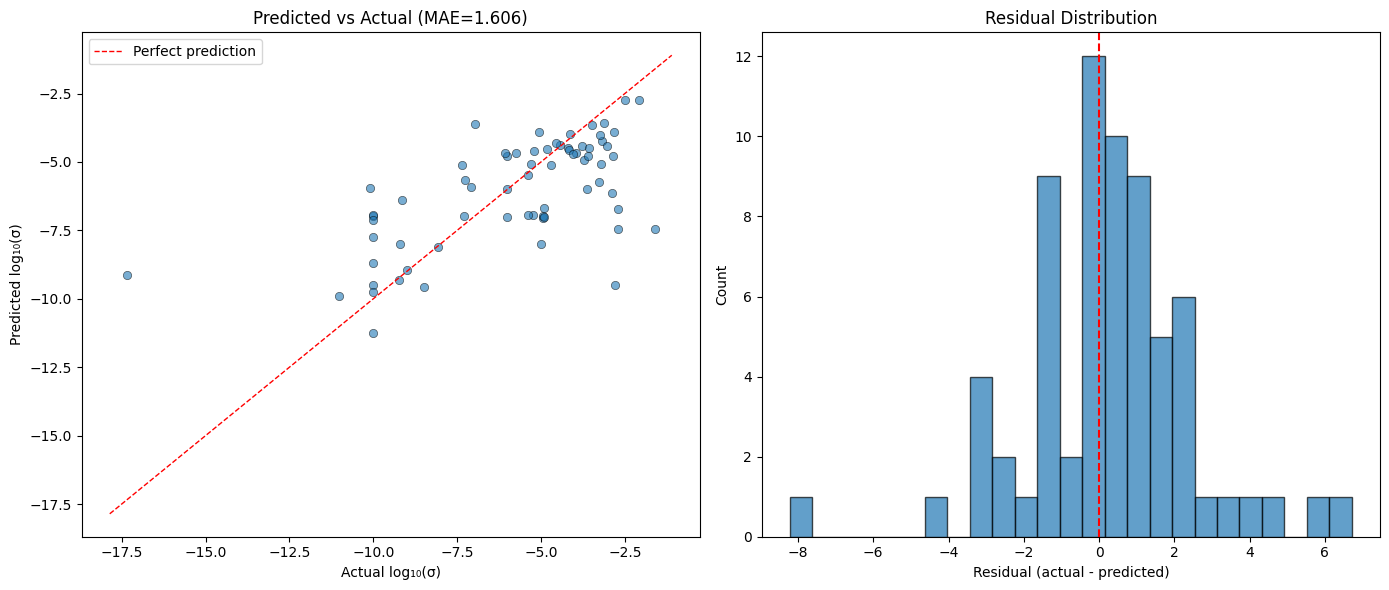

Residual stats:
  Mean:  0.2553
  Std:   2.2500
  Max overpredict (negative residual):  -8.2156
  Max underpredict (positive residual): 6.7183


In [7]:
residuals = y_test - tuned_preds

# Predicted vs actual
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.scatter(y_test, tuned_preds, alpha=0.6, edgecolors='k', linewidth=0.5)
lims = [min(y_test.min(), tuned_preds.min()) - 0.5, max(y_test.max(), tuned_preds.max()) + 0.5]
ax.plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction')
ax.set_xlabel('Actual log₁₀(σ)')
ax.set_ylabel('Predicted log₁₀(σ)')
ax.set_title(f'Predicted vs Actual (MAE={tuned_mae:.3f})')
ax.legend()

ax = axes[1]
ax.hist(residuals, bins=25, edgecolor='k', alpha=0.7)
ax.axvline(0, color='r', linestyle='--')
ax.set_xlabel('Residual (actual - predicted)')
ax.set_ylabel('Count')
ax.set_title('Residual Distribution')

plt.tight_layout()
plt.show()

print(f'Residual stats:')
print(f'  Mean:  {residuals.mean():.4f}')
print(f'  Std:   {residuals.std():.4f}')
print(f'  Max overpredict (negative residual):  {residuals.min():.4f}')
print(f'  Max underpredict (positive residual): {residuals.max():.4f}')

In [8]:
# Worst predictions — these are the materials we need better features for
test_results = test[['id', 'composition', 'log_conductivity']].copy()
test_results['predicted'] = tuned_preds
test_results['residual'] = residuals
test_results['abs_error'] = np.abs(residuals)

worst = test_results.nlargest(10, 'abs_error')

print('Worst 10 predictions:')
print(f'{"Composition":25s} {"Actual":>8s} {"Predicted":>10s} {"Error":>8s}')
print('-' * 55)
for _, row in worst.iterrows():
    print(f'{row["composition"]:25s} {row["log_conductivity"]:8.2f} {row["predicted"]:10.2f} {row["abs_error"]:8.2f}')

Worst 10 predictions:
Composition                 Actual  Predicted    Error
-------------------------------------------------------
Li2NaBP2O8                  -17.36      -9.14     8.22
LiTa2PO8                     -2.80      -9.51     6.72
Li3ClO                       -1.60      -7.46     5.85
Li3YBr6                      -2.72      -7.45     4.73
Li2P2S6                     -10.11      -5.94     4.17
Li3InCl6                     -2.69      -6.71     4.02
(La0.7Li0.3)(Ti0.6Al0.4)O3    -6.98      -3.62     3.36
Li6.05Ga0.25La3Zr2O11.8F0.2    -2.89      -6.13     3.24
Li4Sr3Nb6O20                -10.00      -6.93     3.07
Li4Sr3Nb5.77Fe0.23O19.77    -10.00      -6.97     3.03


## 7. Optuna Optimization History

Shows whether Optuna converged or if more trials would help.

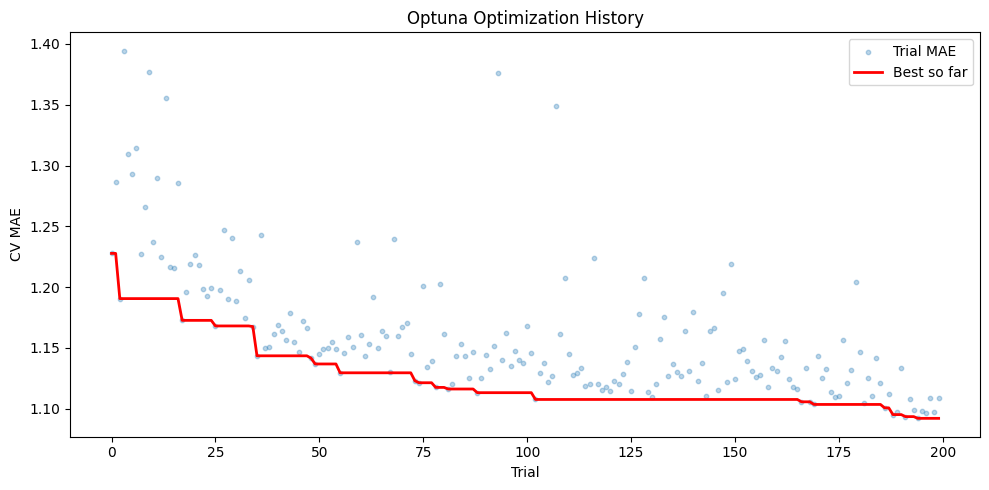

MAE at trial 50:  1.1369
MAE at trial 100: 1.1132
MAE at trial 200: 1.0921

If these are still improving significantly, increase n_trials to 400.


In [9]:
trials = study.trials
trial_values = [t.value for t in trials]
best_so_far = [min(trial_values[:i+1]) for i in range(len(trial_values))]

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(range(len(trial_values)), trial_values, alpha=0.3, s=10, label='Trial MAE')
ax.plot(best_so_far, color='red', linewidth=2, label='Best so far')
ax.set_xlabel('Trial')
ax.set_ylabel('CV MAE')
ax.set_title('Optuna Optimization History')
ax.legend()
plt.tight_layout()
plt.show()

# If the red line is still dropping at trial 200, run more trials
print(f'MAE at trial 50:  {best_so_far[49]:.4f}')
print(f'MAE at trial 100: {best_so_far[99]:.4f}')
print(f'MAE at trial 200: {best_so_far[-1]:.4f}')
print(f'\nIf these are still improving significantly, increase n_trials to 400.')